In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

from ipywidgets import interact, FloatSlider

import sys
sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
import resonance_functions as res_func

In [2]:
#V1
# It uses "resonance_functions.py" for definitions. Make sure the correct path to it is specified in the block above. Keep the r before the "".
# Now it is no longer necessary to use ConvertH5_vKonstanz.ipynb.
# 

#V original:
#Requires running ConvertH5_vKonstanz.ipynb before for the same folder or the data in format *.h5 

#Enter the folder where data is in "address" (do not erase the r)
#Enter the file name that is targeted for the analysis.

#"inPLane" determines if the measurements is done inP or not, and chooses the correct Magnetic field parametrization

In [3]:
#Folder where file is. Keep the r to use raw string in Windows.
#address = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\YIG_Jone_FMR\YIG_side_new_params\FMR_2026-06-05")
address = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\F264N4_p3\inP_010GaAs\FMR_2026-06-10")

In [4]:
#Only modify the name of the target file in file_name
#file_name = "2026-06-05_FMR_fsw_0Ato19p5Ain81_0p5to28p5GHz_0dBm_16-10.h5.ma8"
file_name = "2026-06-10_FMR_fsw_0Ato20Ain81_0p5to50GHz_-10dBm_20-42.h5.ma8"

In [5]:
file = address/file_name

In [6]:
inPlane = True

In [7]:
#user parameters
#Usable with omega_Kalinilos()
Msat_YIG = 139.6e3 #A/m
Aex_YIG = 4.0e-12 #J/m
gamma_YIG = 1.822123739e11
t_YIG = 105*1e-9

In [8]:
def calcField(A, inP): #A current in amper
    #Field for 20mmGap, from Manual (inPlane)
    field1 = 0.01018 + 0.05859*A - 0.00118*(A**2) + 2.1658E-4*(A**3) - 1.77652E-5*(A**4) + 6.35589E-7*(A**5) -1.15951E-8*(A**6) + 1.06504E-10*(A**7) - 3.91644E-13*(A**8)
    #Cal_12152025_Using_ml20240308b2_dS11_5dBm (inPlane)
    field2 = 0.00675 + 0.05052*A + 6.69033E-4*(A**2) - 4.38998E-4*(A**3) + 1.11737E-4*(A**4) - 1.45078E-5*(A**5) + 1.00456E-6*(A**6) - 3.52383E-8*(A**7) + 4.88931E-10*(A**8)
    #Cal_18122025_Using_ml20240308b2_dS11_0dBm (outPlane)
    field_outP = -4.75612131323894e-10*A**8 + 5.53240901595132e-8*A**7 - 2.44397032127303e-6*A**6 + 5.44573750852832e-5*A**5 - 0.000670050456046096*A**4 + 0.00455904626621348*A**3 - 0.0156901329345105*A**2 + 0.0762165481027225*A + 0.0164075279665365

    #Measured by gaussmeter 09/06/2026
    field_inP_mT = -2.791826973437297e-12*A**13 + 2.629557158787310e-10*A**12 - 3.341952544859737e-09*A**11 - 5.932640840884606e-07*A**10 + 3.802178264636290e-05*A**9 - 1.130650994442105e-03*A**8 + 1.996752774903699e-02*A**7 - 2.220353889564056e-01*A**6 + 1.557372478377703e+00*A**5 - 6.643370685736379e+00*A**4 + 1.587659937311382e+01*A**3 - 1.851724704466135e+01*A**2 + 5.928607446113774e+01*A + 6.050126767279399e+00 
    field_inP = field_inP_mT/1000 #T

    #field_inP = (field1 + field2)/2
    #field_inP = field2
    
    if inP == True:
        field = field_inP
    else:
        field = field_outP
    return field #field in T

In [9]:
def plot_fvsH_matplt(field, freq, S11, S12, S21, S22,
                 zmin_reflect=None, zmax_reflect=None,    # for S11, S22
                 zmin_trans=None, zmax_trans=None):        # for S12, S21
    
    #field = field*1e3 #mTf
    sorted_indices = np.argsort(field)
    sorted_field = field[sorted_indices]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

    # To unify 2D grid structure for imshow
    extent = [sorted_field.min(), sorted_field.max(), freq.min(), freq.max()]

    # ---- Row 1 ----
    im11 = axes[0, 0].imshow(S11,
                             extent=extent,
                             aspect='auto',
                             origin='lower',
                             vmin=zmin_reflect, vmax=zmax_reflect)
    axes[0, 0].set_title("S11")

    im12 = axes[1, 1].imshow(S12,
                             extent=extent,
                             aspect='auto',
                             origin='lower',
                             vmin=zmin_trans, vmax=zmax_trans)
    axes[0, 1].set_title("S22")

    # ---- Row 2 ----
    im21 = axes[1, 0].imshow(S21,
                             extent=extent,
                             aspect='auto',
                             origin='lower',
                             vmin=zmin_trans, vmax=zmax_trans)
    axes[1, 0].set_title("S21")

    im22 = axes[0, 1].imshow(S22,
                             extent=extent,
                             aspect='auto',
                             origin='lower',
                             vmin=zmin_reflect, vmax=zmax_reflect)
    axes[1, 1].set_title("S12")

    # Shared labels
    axes[1, 0].set_xlabel("Field")
    axes[1, 1].set_xlabel("Field")
    axes[0, 0].set_ylabel("Frequency")
    axes[1, 0].set_ylabel("Frequency")

    # ---- Colorbars using make_axes_locatable ----
    # Reflection (S11 + S22)
    divider = make_axes_locatable(axes[0,1])
    cax_reflect = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(im11, cax=cax_reflect, label="Reflection magnitude")

    # Transmission (S12 + S21)
    divider = make_axes_locatable(axes[1,1])
    cax_trans = divider.append_axes("right", size="3%", pad=0.1)
    fig.colorbar(im12, cax=cax_trans, label="Transmission magnitude")

    fig.tight_layout()
    #plt.show()
    return fig, axes


In [10]:
def plot_fvsH_onlyij(field, freq, S12, S21, which,
                 zmin_trans=None, zmax_trans=None):        # for S12, S21
    
    #field = field*1e3 #mT
    #sorted_indices = np.argsort(field)
    #sorted_field = field[sorted_indices]
    sorted_field = field 
    #S12 = S12[sorted_indices]
    #S21 = S21[sorted_indices]
    fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharex=True, sharey=True)

    # To unify 2D grid structure for imshow
    extent = [sorted_field.max(), sorted_field.min(), freq.min(), freq.max()]

    # ---- Row 1 ----
    if which == '21':
        im11 = axes.imshow(S21,
                                 extent=extent,
                                 aspect='auto',
                                 origin='lower',
                                 vmin=zmin_trans, vmax=zmax_trans)
        axes.set_title("S21", fontsize=20)
    else:
        im11 = axes.imshow(S12,
                                 extent=extent,
                                 aspect='auto',
                                 origin='lower',
                                 vmin=zmin_trans, vmax=zmax_trans)
        axes.set_title("S12", fontsize=20)


    # Shared labels
    axes.set_xlabel("Applied magnetic Field (T)", fontsize=16)
    axes.set_ylabel("Frequency (GHz)", fontsize=16)

    # ---- Colorbars using make_axes_locatable ----
    # Transmission (S12 + S21)
    divider = make_axes_locatable(axes)
    cax_trans = divider.append_axes("right", size="3%", pad=0.1)
    cbar = fig.colorbar(im11, cax=cax_trans, label="Transmission magnitude")
    cbar.ax.tick_params(labelsize=16) 

    fig.tight_layout()
    #plt.show()
    return fig, axes

In [11]:
# Importing data. Open the HDF5 file
with h5py.File(file, "r") as f:
    #NumPy arrays
    S11R = f["/data/VNA d_S11R"][:]
    S11I = f["/data/VNA d_S11I"][:]
    S21R = f["/data/VNA d_S21R"][:]
    S21I = f["/data/VNA d_S21I"][:]
    S12R = f["/data/VNA d_S12R"][:]
    S12I = f["/data/VNA d_S12I"][:]
    S22R = f["/data/VNA d_S22R"][:]
    S22I = f["/data/VNA d_S22I"][:]
    
    freqs = f["/data/VNA frequency"][0, :]*1e-9 #GHz
    currs = f["/data/magnet current"][:] #A
    #fields = f["/data/magnet field"][:] #T
    power = f["/data/VNA power"][0]

#Bulding dS matrix
dS_matrix = {"dS11": S11R + 1j * S11I, "dS21": S21R + 1j * S21I,
                   "dS22": S22R + 1j * S22I, "dS12": S12R + 1j * S12I,}

In [12]:
print(currs)

[19.99 19.74 19.49 19.24 19.   18.75 18.5  18.25 17.99 17.75 17.5  17.24
 17.   16.74 16.49 16.24 16.   15.74 15.5  15.24 14.99 14.74 14.49 14.24
 13.99 13.74 13.49 13.24 12.99 12.75 12.5  12.25 11.99 11.75 11.5  11.25
 11.   10.75 10.49 10.24  9.99  9.75  9.49  9.24  8.99  8.74  8.49  8.24
  7.99  7.74  7.49  7.24  6.99  6.74  6.49  6.25  5.99  5.75  5.49  5.24
  4.99  4.74  4.49  4.24  3.99  3.74  3.49  3.24  2.99  2.74  2.49  2.24
  1.99  1.74  1.49  1.24  0.99  0.74  0.49  0.24  0.  ]


In [13]:
#Determine field points
fields = calcField(currs, inPlane) #T
field_pts = len(fields)
#Fields for traces
plot_fields = np.linspace(fields.min(), fields.max(), 100) #T

In [48]:
def f_vs_H_manipulation_ij(Derivative=False, z_R=200, z_T=0, ij='21', gamma=29, Hx=Msat_YIG*res_func.mu_0*1000, Hy=0 ):
    """In the parameters enter the initial values. 
    gamma (GHz/T)
    Hx, Hy (T)
    """
    Hx_T = Hx/1000 #T
    Hy_T = Hy/1000 #T
    
    colors = ['magenta', 'cyan', 'red', 'blue', 'hotpink']
    if Derivative:
        fig_manip, axes = plot_fvsH_onlyij(fields, freqs, D_dSij_dH["D_dS12M_DH_R"].T, D_dSij_dH["D_dS21M_DH_R"].T, ij,
                                           zmin_trans=-z_T, zmax_trans=z_T)
    else:
        fig_manip, axes = plot_fvsH_onlyij(fields, freqs, abs(dS_matrix["dS12"].T), abs(dS_matrix["dS21"].T), ij,
                                            zmin_trans=-z_T, zmax_trans=z_T)

    # To add a trace
    def add_trace(plt, axes, func, color, tlt):
        axes.plot(plot_fields, func, lw=2, color=color, label=tlt)
        axes.legend(loc="lower right", fontsize=14)
        axes.xaxis
    
    add_trace(fig_manip, axes, res_func.kittel_general(gamma, plot_fields, Hx_T, Hy_T), 'red','Adjustment_FMR')
    

    axes.set_xlim(0, fields.max())
    axes.set_ylim(freqs.min(),freqs.max())
    #axes.set_xlim(0, 0.15)
    #axes.set_ylim(freqs.min(), 15)

    axes.tick_params(axis="both", labelsize=16)
    
    fig_manip.canvas.draw()
    plt.show()

In [50]:
#Calculate derivatives
dS21_dH = np.gradient(dS_matrix["dS21"], fields, axis=0)
dS21_M_dH = np.gradient(abs(dS_matrix["dS21"]), fields, axis=0)
dS12_dH = np.gradient(dS_matrix["dS12"], fields, axis=0)
dS12_M_dH = np.gradient(abs(dS_matrix["dS12"]), fields, axis=0)

D_dSij_dH ={
        "D_dS21_DH_M": abs(np.array(dS21_dH)), "D_dS21M_DH_M": abs(np.array(dS21_M_dH)),
        "D_dS21M_DH_R": np.array(dS21_M_dH).real,
        "D_dS12_DH_M": abs(np.array(dS12_dH)), "D_dS12M_DH_M": abs(np.array(dS12_M_dH)),
        "D_dS12M_DH_R": np.array(dS12_M_dH).real
            }

In [51]:
#Interactive sliders
interact(f_vs_H_manipulation_ij,
        Derivative=[False,True],
        z_R=FloatSlider(value=0.05, min=-5, max=5, step=0.01, readout_format='.2f', description=r"Contrast ii"),
        z_T=FloatSlider(value=0.005, min=-0.005, max=1, step=0.001, readout_format='.4f', description=r"Contrast ij"),
        ij=['12', '21'],
        gamma=FloatSlider(value=28.8, min=27, max=30, step=0.1, readout_format='.2f', description=r"gamma (GHz/T)"),
        Hx=FloatSlider(value=2180, min=-100, max=2500, step=1, readout_format='.2f', description=r"Hx (mT)"),
        Hy=FloatSlider(value=40, min=-100, max=500, step=5, readout_format='.2f', description=r"Hy (mT)"),
);

interactive(children=(Dropdown(description='Derivative', options=(False, True), value=False), FloatSlider(valu…

In [17]:
print(fields)

[1.01184324 1.00242484 0.99280074 0.98294652 0.97324209 0.96284605
 0.95212191 0.94103491 0.92908535 0.91765022 0.90530633 0.89198942
 0.87926237 0.86501446 0.85088454 0.8363652  0.82209915 0.80633522
 0.79155408 0.7753602  0.75968163 0.74396914 0.72829311 0.71272162
 0.69731838 0.68214092 0.6672389  0.65265279 0.63841284 0.62508623
 0.61157055 0.59842605 0.58513539 0.57318864 0.5610415  0.54915964
 0.53749898 0.52601176 0.51419588 0.50290948 0.49164914 0.48082401
 0.4690414  0.45762699 0.44610697 0.43446816 0.42270638 0.41082621
 0.39884042 0.38676895 0.3746374  0.36247535 0.35031424 0.33818519
 0.32611666 0.31460967 0.3022481  0.29094113 0.27880173 0.26722319
 0.25571191 0.24423291 0.23274253 0.22119101 0.2095259  0.19769639
 0.18565821 0.17337895 0.16084333 0.14805793 0.13505464 0.12189202
 0.10865328 0.09543978 0.0823582  0.06949953 0.05690765 0.04453469
 0.03218025 0.01941083 0.00605013]


In [18]:
curr1 = 19.5#17.55
h1 = calcField(curr1, inPlane)
print(h1)
float(res_func.kittel_general(28.9, h1, 0.177, 0))

0.9931899359968084


31.156034581745388

In [19]:
float(np.arccos(0.9078/0.9932)*180/np.pi)

23.933728034396008

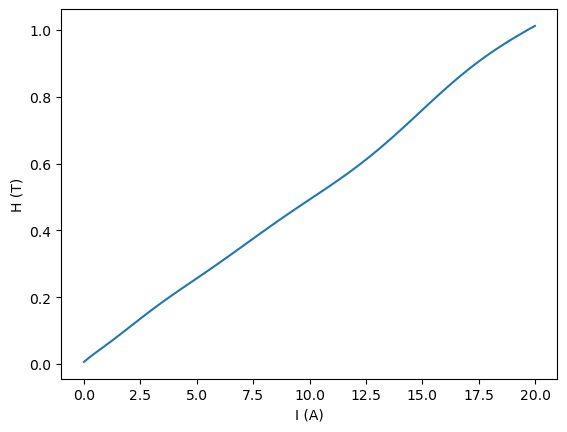

In [20]:
plt.plot(currs, fields)
plt.xlabel("I (A)")
plt.ylabel("H (T)")
plt.show()